# Giới thiệu về Tensor

Nếu ta đã từng làm việc với Numpy, thì Tensor cũng giống như các mảng Numpy

- Ta có thể hình dùng Tensor như 1 biểu diễn số đa chiều (*n chiều*) của 1 thứ gì đó. trong đó thứ gì đó có thể mọi thứ mà ta có thể tưởng tượng (*hình ảnh, văn bản, số, chữ, ...*)

In [ ]:
import tensorflow as tf

print(f"Tensorflow version : {tf.__version__}")

Tensorflow version : 2.19.0


# Tạo Tensor với `tf.constant()`

Như đã đề cập trước đó, nhìn chung, ta thường sẽ không tự tạo tensor. Điều này là do TensorFlow có các module tích hợp sẵn (*như tf.io và tf.data*) có khả năng đọc nguồn dữ liệu của ta và tự động chuyển đổi chúng thành tensor, sau đó các mô hình mạng nơ-ron sẽ xử lý chúng cho ta.

Nhưng hiện tại, vì chúng ta đã quen với tenxơ và cách thao tác với chúng, chúng ta sẽ xem cách tự tạo ra chúng.

Để tạo ra 1 tensor ta sẽ cần tới `tf.constant()`

In [ ]:
scalar = tf.constant(7)
scalar

<tf.Tensor: shape=(), dtype=int32, numpy=7>

Một scalar (*số vô hướng*) được gọi là Tensor bậc 0. Bởi vì nó không có chiều (*nó chỉ là một con số*).

Ta có thể quan sát ở `shape` của chính nó, hiện tại đang không hiển thị gì hết - điều này có nghĩa là nó là 1 Tensor 0 chiều.

In [ ]:
# Check the number of dimensions of a scalar tensor
scalar.ndim

0

Ta cũng sẽ tạo 1 vector (*tensor có 1 chiều*) để quan sát xem nó thế nào

In [ ]:
vector = tf.constant([8, 10])
vector

<tf.Tensor: shape=(2,), dtype=int32, numpy=array([ 8, 10], dtype=int32)>

Ta cũng có thể tạo 1 matrix (*1 tensor có 2 chiều*)

In [ ]:
matrix = tf.constant([[10, 7],
                      [7, 10]])
matrix

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[10,  7],
       [ 7, 10]], dtype=int32)>

Chắc chắn ta cũng có thể tạo ra 1 Tensor (*1 tensor có nhiều hơn 2 chiều*)

In [ ]:
tensor = tf.constant([[[1, 2, 3],
                       [4, 5, 6]],
                      [[7, 8, 9],
                       [10, 11, 12]],
                      [[13, 14, 15],
                       [16, 17, 18]]])
tensor

<tf.Tensor: shape=(3, 2, 3), dtype=int32, numpy=
array([[[ 1,  2,  3],
        [ 4,  5,  6]],

       [[ 7,  8,  9],
        [10, 11, 12]],

       [[13, 14, 15],
        [16, 17, 18]]], dtype=int32)>

---
Theo mặc định Tensorflow sẽ tạo ra các Tensor có kiểu dữ liệu là int32 hoặc float32.

Nhưng ta có thể đặt cho các dữ liệu trong Tensor của mình là loại nào.

In [ ]:
matrix_2 = tf.constant([[2, 3],
                        [4, 5]], dtype=tf.float16)
matrix_2

<tf.Tensor: shape=(2, 2), dtype=float16, numpy=
array([[2., 3.],
       [4., 5.]], dtype=float16)>

# Tạo Tensor với `tf.Variable()`

Ta cũng có thể tạo tenxơ bằng cách sử dụng `tf.Variable()`.

Sự khác biệt giữa `tf.Variable()` và `tf.constant()` là các tenxơ được tạo bằng `tf.constant()` là bất biến (*không thể thay đổi*), trong khi các tenxơ được tạo bằng `tf.Variable()` là có thể thay đổi.

Nhưng quy trình để tạo ra 1 tensor thì hoàn toàn giống nhau.

In [ ]:
change_tensor = tf.Variable([10, 7])
unchange_tensor = tf.constant([10, 7])

change_tensor, unchange_tensor

(<tf.Variable 'Variable:0' shape=(2,) dtype=int32, numpy=array([10,  7], dtype=int32)>,
 <tf.Tensor: shape=(2,), dtype=int32, numpy=array([10,  7], dtype=int32)>)

Nhưng việc thay đổi giá trị trong Tensor không giống như việc thay đổi 1 giá trị trong mảng - là đặt chỉ số trong `[]` và thực hiện phép gán.

Và điều này sẽ gây ra lỗi

In [ ]:
change_tensor[0] = 7
change_tensor

NameError: name 'chứchange_tensor' is not defined

Để thay đổi một phần tử của tenxor `tf.Variable()` ta cần có phương thức `assign()`.


In [ ]:
change_tensor[0].assign(7)
change_tensor

<tf.Variable 'Variable:0' shape=(2,) dtype=int32, numpy=array([7, 7], dtype=int32)>

Ta cũng hãy thử thay đổi 1 phần tử trong tensor sử dụng `tf.constant()` - và điều này chắc chắn sẽ gặp lỗi

In [ ]:
unchange_tensor[0].assign(7)
unchange_tensor

AttributeError: 'tensorflow.python.framework.ops.EagerTensor' object has no attribute 'assign'

# Tạo 1 random Tensor

Tensor ngẫu nhiên là Tensor có một số kích thước tùy ý chứa các số ngẫu nhiên.

> Tại sao ta lại muốn tạo ra tenxơ ngẫu nhiên?
>
> => Đây là những gì mạng nơ-ron sử dụng để khởi tạo weight (*pattens*) mà chúng đang cố gắng học trong dữ liệu

Ví dụ, quá trình học mạng nơ-ron thường bao gồm việc lấy một mảng số n chiều ngẫu nhiên và tinh chỉnh chúng cho đến khi chúng biểu diễn một số dạng pattens (*một cách nén để biểu diễn dữ liệu gốc*).

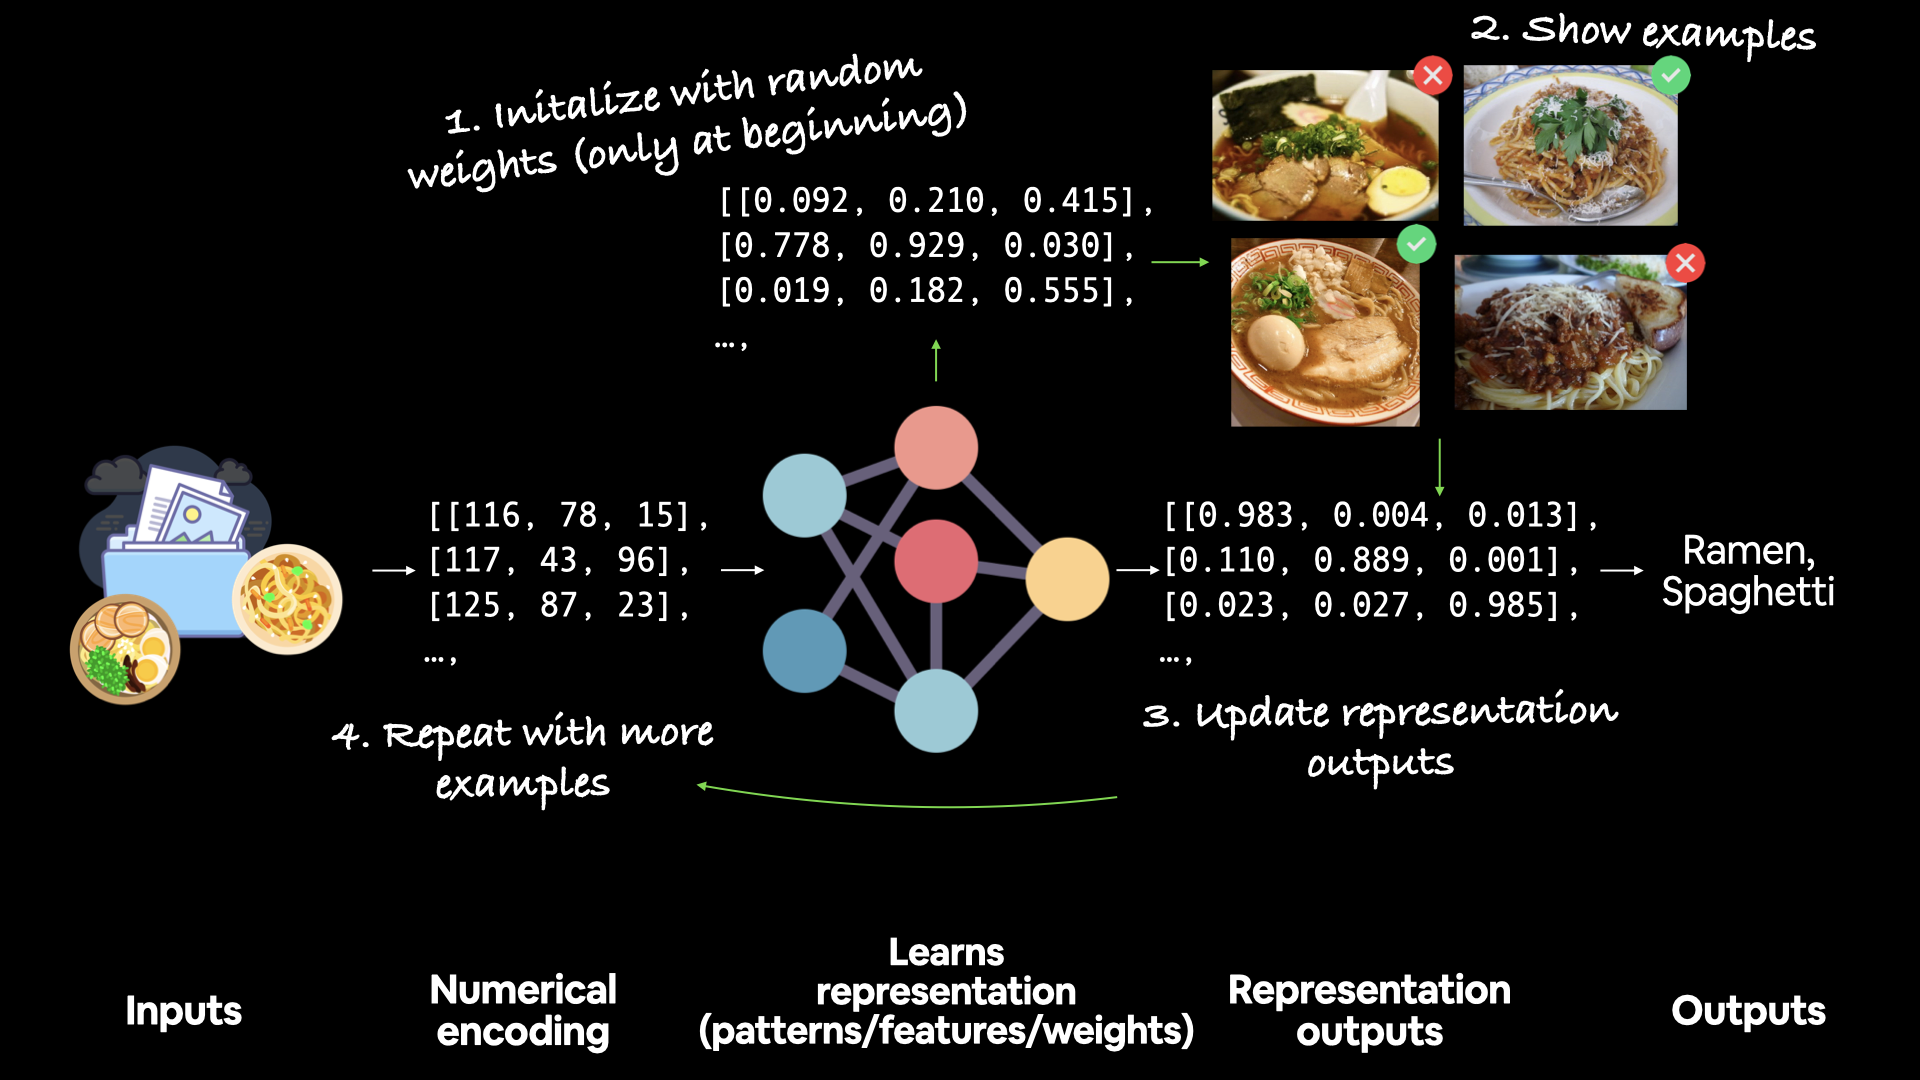

Ta có thể tạo ra các Tensor ngẫu nhiên bằng cách sử dụng lớp `tf.random.Generator`.

In [ ]:
random_1 = tf.random.Generator.from_seed(42) # set seed for random state
random_1 = random_1.normal(shape=(3, 2))

random_2 = tf.random.Generator.from_seed(42) # set seed for random state
random_2 = random_2.normal(shape=(3, 2))

# are they equal ?
random_1, random_2, random_1 == random_2

(<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
 array([[-0.7565803 , -0.06854702],
        [ 0.07595026, -1.2573844 ],
        [-0.23193763, -1.8107855 ]], dtype=float32)>,
 <tf.Tensor: shape=(3, 2), dtype=float32, numpy=
 array([[-0.7565803 , -0.06854702],
        [ 0.07595026, -1.2573844 ],
        [-0.23193763, -1.8107855 ]], dtype=float32)>,
 <tf.Tensor: shape=(3, 2), dtype=bool, numpy=
 array([[ True,  True],
        [ True,  True],
        [ True,  True]])>)

Các tensor mà ta vừa tạo ở trên hoàn toàn giống nhau khi ta tùy chỉnh `shape` của chúng giống nhau.

Điều này nghĩa là Chúng là các Tensor ngẫu nhiên nhưng thức ra không phải vậy.

Nếu ta đặt một `seed`, ta sẽ nhận được các số ngẫu nhiên giống nhau.

## Xáo trộn dữ liệu bằng `random.shuffle()`
Ta cũng có thể muốn làm xáo trộn các phần từ bên trong Tensor của mình.

> Vì sao ta lại muốn làm như vậy ?
>
> Ví dụ ta có 10000 dữ liệu của các bức ảnh chó và mèo, trong đó 5000 dữ liệu đầu tiên là của mèo và 5000 dữ liệu sau đó là của chó. Điều này có thể khiến qua trình learn mô hình của mình gặp vấn đề overfit. **Vì vậy ta sẽ cần xáo trôn nó**.



In [ ]:
tensor_shuffle = tf.constant([[10, 7],
                            [3, 4],
                            [2, 5]])

# Gets different results each time
tf.random.shuffle(tensor_shuffle)

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[10,  7],
       [ 3,  4],
       [ 2,  5]], dtype=int32)>

Nếu ta thực hiện việc run nó nhiều lần ta sẽ thấy mỗi lần nó sẽ đưa ra các phần tử được nằm ở các vị trí khác nhau.

Ta sẽ thử việc set thêm tham số `seed` cho nó

In [ ]:
tf.random.shuffle(tensor_shuffle, seed=42)

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[ 2,  5],
       [ 3,  4],
       [10,  7]], dtype=int32)>

Tuy đã có thêm tham số `seed` nhưng nó vẫn thay đổi chứ không dữ nguyên

Điều này là do ta chưa đặt global seed cho nó mà ta chỉ mới đặt operation seed.

> Để nó có thể dữ nguyên giá trị, ta cần phải set cả 2 seed

In [ ]:
tf.random.set_seed(42) # set global seed

tf.random.shuffle(tensor_shuffle, seed=42) # set operation seed

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[10,  7],
       [ 3,  4],
       [ 2,  5]], dtype=int32)>

OK bây giờ thì dù ta thực thi nó bao nhiêu lần thì nó vẫn chỉ dữ 1 giá trị.

Hoặc ta chỉ cần set global seed mà không set operation seed thì nó vấn hoạt động, nhưng nó có giá trị không giống với khi ta set cả 2 seed

In [ ]:
tf.random.set_seed(42) # set global seed

tf.random.shuffle(tensor_shuffle)

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[ 3,  4],
       [ 2,  5],
       [10,  7]], dtype=int32)>

# Những cách khác để tạo ra Tensor
Mặc dù hiếm khi sử dụng những thứ này, nhưng ta có thể sử dụng `tf.ones()` để tạo một Tensor gồm toàn số 1 và `tf.zeros()` để tạo một Tensor gồm toàn số 0.


In [ ]:
tf.ones(shape=(3, 2))

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[1., 1.],
       [1., 1.],
       [1., 1.]], dtype=float32)>

In [ ]:
tf.zeros(shape=(3, 2))

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[0., 0.],
       [0., 0.],
       [0., 0.]], dtype=float32)>

Ta cũng có thể chuyển mảng NumPy thành Tensor

In [ ]:
import numpy as np

numpy_A = np.arange(1, 25, dtype=np.int32) # create a NumPy array between 1 and 25

# note: the shape total (2*4*3) has to match the number of elements in the array
A = tf.constant(numpy_A,
                shape=[2, 4, 3])

numpy_A, A

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24], dtype=int32),
 <tf.Tensor: shape=(2, 4, 3), dtype=int32, numpy=
 array([[[ 1,  2,  3],
         [ 4,  5,  6],
         [ 7,  8,  9],
         [10, 11, 12]],
 
        [[13, 14, 15],
         [16, 17, 18],
         [19, 20, 21],
         [22, 23, 24]]], dtype=int32)>)

# Lấy thông tin từ tensor
Sẽ có những lúc ta muốn lấy những thông tin khác nhau từ tensor của mình:

- `shape`: Độ dài (*số phần tử*) của mỗi chiều của một tensor.

- `ndim` hoặc **rank**: Số chiều tensor. Một scalar có rank là 0, một vector có rank là 1, một matrix có rank là 2, một tensor có rank là n.

- `size`: Tổng số item trong tensor

- `dtype`: Lấy kiểu dữ liệu của các phần từ trong Tensor

In [ ]:
rank_4_tensor = tf.zeros([2, 3, 4, 5])
rank_4_tensor

<tf.Tensor: shape=(2, 3, 4, 5), dtype=float32, numpy=
array([[[[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]]],


       [[[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]]]], dtype=float32)>

In [ ]:
rank_4_tensor.shape, rank_4_tensor.ndim, tf.size(rank_4_tensor)

(TensorShape([2, 3, 4, 5]), 4, <tf.Tensor: shape=(), dtype=int32, numpy=120>)

In [ ]:
print("Datatype of every element:", rank_4_tensor.dtype)
print("Number of dimensions (rank):", rank_4_tensor.ndim)
print("Shape of tensor:", rank_4_tensor.shape)
print("Elements along axis 0 of tensor:", rank_4_tensor.shape[0])
print("Elements along last axis of tensor:", rank_4_tensor.shape[-1])
print("Total number of elements (2*3*4*5):", tf.size(rank_4_tensor).numpy())

Datatype of every element: <dtype: 'float32'>
Number of dimensions (rank): 4
Shape of tensor: (2, 3, 4, 5)
Elements along axis 0 of tensor: 2
Elements along last axis of tensor: 5
Total number of elements (2*3*4*5): 120


Ta cũng có thể lập chỉ mục cho tensor giống như list trong Python.

In [ ]:
# Get the first 2 items of each dimension
rank_4_tensor[:2, :2, :2, :2]

<tf.Tensor: shape=(2, 2, 2, 2), dtype=float32, numpy=
array([[[[0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.]]],


       [[[0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.]]]], dtype=float32)>

In [ ]:
# Get the dimension from each index except for the final one
rank_4_tensor[:1, :1, :1, :]

<tf.Tensor: shape=(1, 1, 1, 5), dtype=float32, numpy=array([[[[0., 0., 0., 0., 0.]]]], dtype=float32)>

In [ ]:
# Create a rank 2 tensor (2 dimensions)
rank_2_tensor = tf.constant([[10, 7],
                             [3, 4]])

rank_2_tensor[:, -1]

<tf.Tensor: shape=(2,), dtype=int32, numpy=array([7, 4], dtype=int32)>

Ta cũng có thể thêm kích thước vào tensor của mình trong khi vẫn giữ nguyên thông tin bằng cách sử dụng `tf.newaxis`

In [ ]:
# Add an extra dimension (to the end)
rank_3_tensor = rank_2_tensor[..., tf.newaxis] # in Python "..." means "all dimensions prior to"
rank_2_tensor, rank_3_tensor # shape (2, 2), shape (2, 2, 1)

(<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
 array([[10,  7],
        [ 3,  4]], dtype=int32)>,
 <tf.Tensor: shape=(2, 2, 1), dtype=int32, numpy=
 array([[[10],
         [ 7]],
 
        [[ 3],
         [ 4]]], dtype=int32)>)

Ta cũng có thể đạt được điều tương tự bằng cách sử dụng `tf.expand_dims()`.

In [ ]:
tf.expand_dims(rank_2_tensor, axis=-1)

<tf.Tensor: shape=(2, 2, 1), dtype=int32, numpy=
array([[[10],
        [ 7]],

       [[ 3],
        [ 4]]], dtype=int32)>

# Các phép toán với Tensor


## Các thao tác cơ bản
Ta có thể thực hiện nhiều phép toán cơ bản trực tiếp trên tensor bằng các toán tử Pyhton như `+`, `-`, `*`.

In [ ]:
tensor = tf.constant([[10, 7], [3, 4]])
tensor + 10

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[20, 17],
       [13, 14]], dtype=int32)>

In [ ]:
tensor * 10

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[100,  70],
       [ 30,  40]], dtype=int32)>

In [ ]:
tensor - 10

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[ 0, -3],
       [-7, -6]], dtype=int32)>

Tuy nhiên vì ta không gán lại và vì tensor của ta là `tf.constant` nên nó sẽ không có sự thay đổi đối với đối tượng gốc

In [ ]:
tensor # origin tensor

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[10,  7],
       [ 3,  4]], dtype=int32)>

## Phép nhân ma trận
TensorFlow triển khai chức năng nhân ma trận này trong phương thức `tf.matmul()`.

Có 2 quy tắc chính cần nhớ khi nhân ma trận là:

1. Kích thước (*dimension*) bên trong phải phù hợp
  
  - `(3, 5) @ (3, 5)` sẽ không hoạt động
  - `(5, 3) @ (3, 5)` sẽ hoạt động
  - `(3, 5) @ (5, 3)` sẽ hoạt động

2. Ma trận kết quả có shape của các chiều bên ngoài:

- `(5, 3) @ (3, 5) -> (5, 5)`
- `(3, 5) @ (5, 3) -> (3, 3)`

    > 🔑 Lưu ý: `'@'` trong Python là ký hiệu để nhân ma trận.

In [ ]:
print(tensor)
tf.matmul(tensor, tensor)

tf.Tensor(
[[10  7]
 [ 3  4]], shape=(2, 2), dtype=int32)


<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[121,  98],
       [ 42,  37]], dtype=int32)>

Hoặc thay vì sử dụng `tf.matmul()` ta có thể sử dụng toán tử `'@'`

In [ ]:
tensor @ tensor

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[121,  98],
       [ 42,  37]], dtype=int32)>

Nếu ta nhân 2 biến tensor với nhau, tuy rằng nó có chung `shape` nhưng các giá trị bên trong nó giống nhau nên ta có thể thực hiện được việc này bình thường.

Ta có thể thử nghiệm với 2 tensor có chung shape nhưng giá trị của chúng lại khác nhau hoàn toàn. Khi thực hiện phép nhân ma trận nó sẽ xảy ra lỗi.

In [ ]:
X = tf.constant([[1, 2],
                 [3, 4],
                 [5, 6]])

# Create another (3, 2) tensor
Y = tf.constant([[7, 8],
                 [9, 10],
                 [11, 12]])

X @ Y

InvalidArgumentError: {{function_node __wrapped__MatMul_device_/job:localhost/replica:0/task:0/device:CPU:0}} Matrix size-incompatible: In[0]: [3,2], In[1]: [3,2] [Op:MatMul] name: 

Chúng ta cần:
- Thay đổi shape của X thành (2, 3) sao cho nó là (2, 3) @ (3, 2).
- Hoặc thay đổi shape của Y thành (3, 2) sao cho nó là (3, 2) @ (2, 3)

Ta có thể thực hiện việc này bằng một trong hai cách sau:
- `tf.reshape()` - cho phép chúng ta định hình lại một tensor thành một shape xác định.
- `tf.transpose()` - chuyển đổi dimensions của một tensor cho trước.

\
Trước tiên ta hãy thử với `tf.reshape()`.

In [ ]:
tf.reshape(Y, shape=(2, 3))

<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
array([[ 7,  8,  9],
       [10, 11, 12]], dtype=int32)>

In [ ]:
X @ tf.reshape(Y, shape=(2, 3))

<tf.Tensor: shape=(3, 3), dtype=int32, numpy=
array([[ 27,  30,  33],
       [ 61,  68,  75],
       [ 95, 106, 117]], dtype=int32)>

Nó đã hoạt động tốt, ta hãy thử làm tương tự với tensor X, ngoại trừ lần này ta sẽ sử dụng `tf.transpose()`

In [ ]:
tf.transpose(X)

<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
array([[1, 3, 5],
       [2, 4, 6]], dtype=int32)>

In [ ]:
tf.transpose(X) @ Y

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[ 89,  98],
       [116, 128]], dtype=int32)>

# Tích vô hướng - dot product

Nhân các ma trận với nhau cũng được gọi là phép **tích vô hướng**. Ta có thể thực hiện phép toán `tf.matmul()` bằng cách sử dụng `tf.tensordot()`.

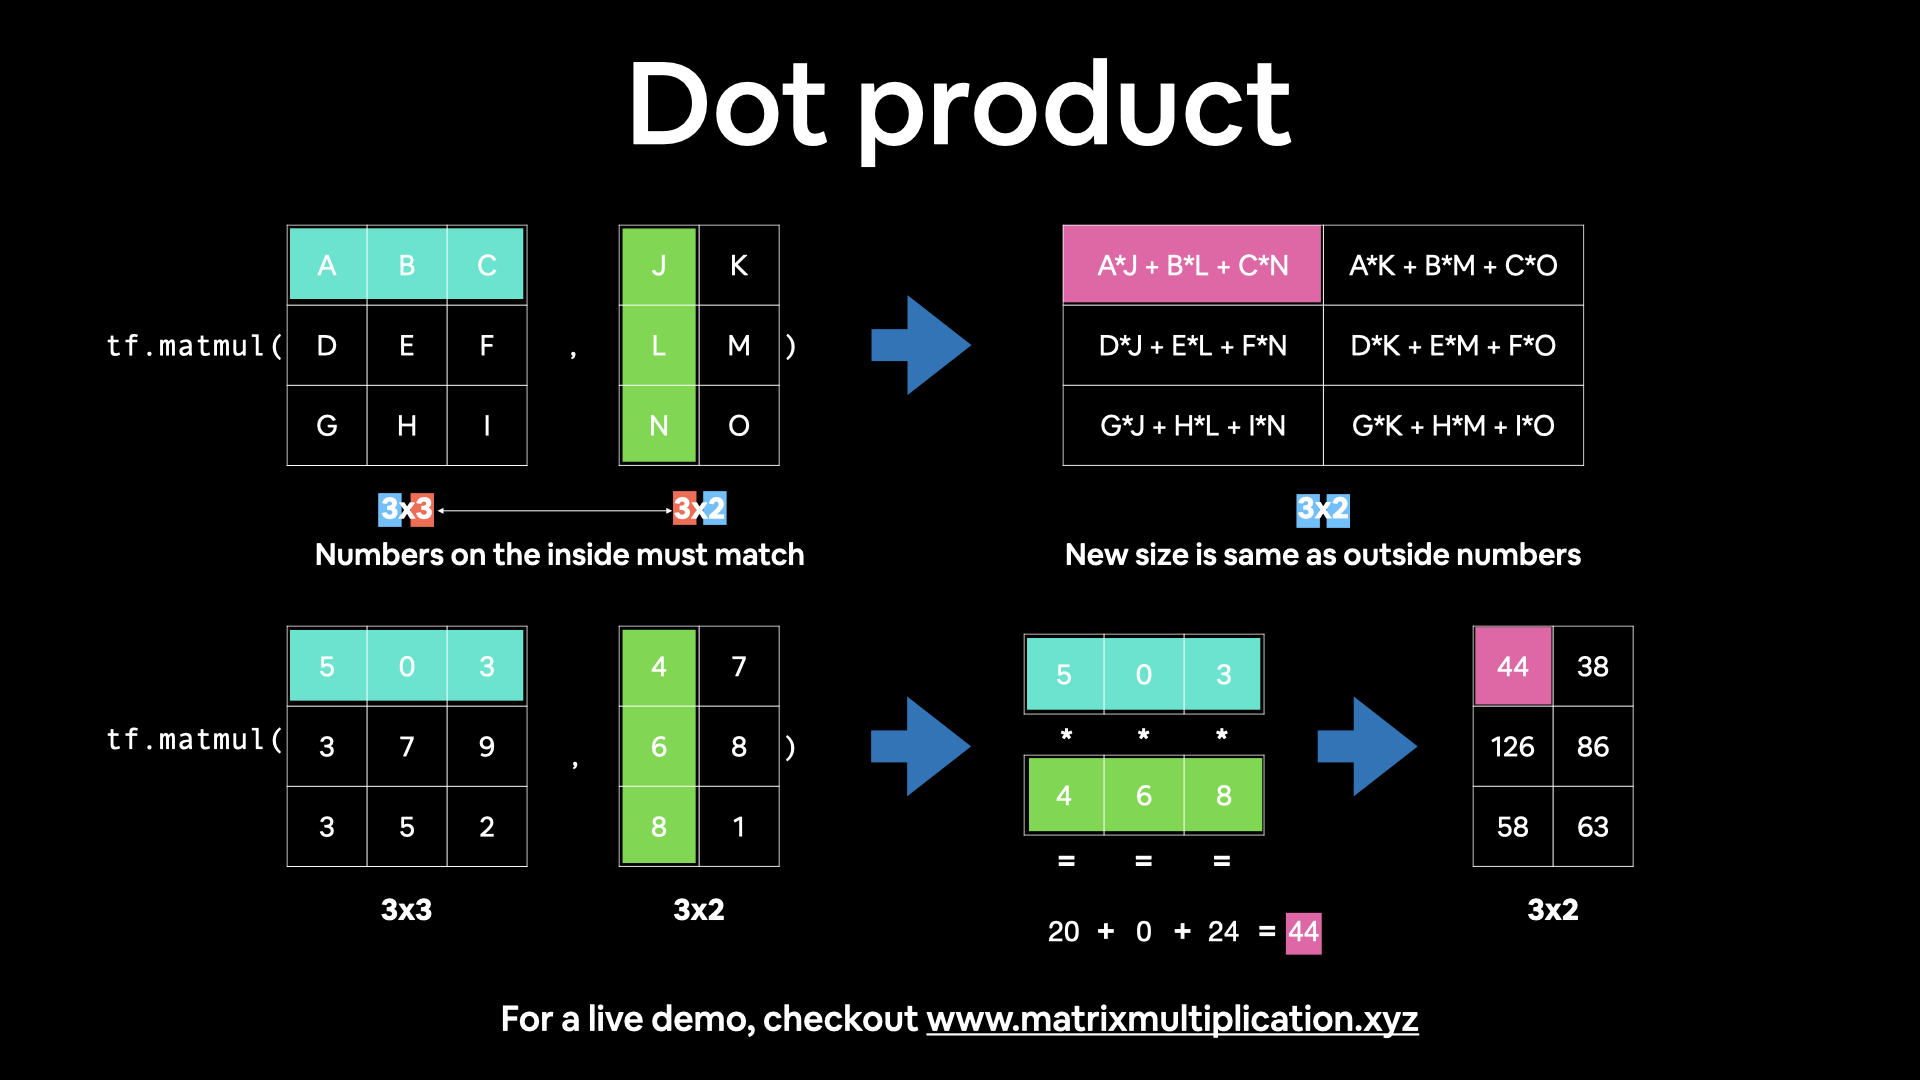

In [ ]:
tf.tensordot(tf.transpose(X), Y, axes=1)

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[ 89,  98],
       [116, 128]], dtype=int32)>

In [ ]:
tf.tensordot(X, tf.reshape(Y, shape=(2, 3)), axes=1)

<tf.Tensor: shape=(3, 3), dtype=int32, numpy=
array([[ 27,  30,  33],
       [ 61,  68,  75],
       [ 95, 106, 117]], dtype=int32)>

---
Ta có thể nhận thấy rằng mặc dù sử dụng cả `reshape` và `transpose`, ta sẽ nhận được kết quả khác nhau khi sử dụng từng công cụ.

Ta hãy xem 1 ví dụ, trước tiên là với `tf.transpose()` sau đó là với `tf.reshape()`.

In [ ]:
tf.matmul(X, tf.transpose(Y))

<tf.Tensor: shape=(3, 3), dtype=int32, numpy=
array([[ 23,  29,  35],
       [ 53,  67,  81],
       [ 83, 105, 127]], dtype=int32)>

In [ ]:
tf.matmul(X, tf.reshape(Y, (2, 3)))

<tf.Tensor: shape=(3, 3), dtype=int32, numpy=
array([[ 27,  30,  33],
       [ 61,  68,  75],
       [ 95, 106, 117]], dtype=int32)>

Tuy rằng sau khi thực hiện `transpose` và `reshape` với `new shape = (2, 3)` có nghĩa là shape của Y bây giờ là giống nhau.

Nhưng chúng đưa ra 2 kết quả với các giá trị trong **Result Tensor** là khác nhau.

In [ ]:
Y.shape, tf.transpose(Y).shape, tf.reshape(Y, (2, 3)).shape

(TensorShape([3, 2]), TensorShape([2, 3]), TensorShape([2, 3]))

Tuy nhiên, chúng có thể có `shape` giống nhau, nhưng điều đó không có nghĩa là vị trí các giá trị của chúng cũng được đặt giống nhau

In [ ]:
print(f"Original Y: \n{Y}\n")
print(f"Transposed Y: \n{tf.transpose(Y)}\n")
print(f"Reshaped Y: \n{tf.reshape(Y, (2, 3))}")

Original Y: 
[[ 7  8]
 [ 9 10]
 [11 12]]

Transposed Y: 
[[ 7  9 11]
 [ 8 10 12]]

Reshaped Y: 
[[ 7  8  9]
 [10 11 12]]


Như ta có thể thấy, output của `tf.reshape()` và `tf.transpose()` khi được gọi đến `Y` mặc dù chúng có `shape` giống nhau nhưng vị trí các phần tử được xắp xếp ở nhưng nơi khác nhau.

> Đây chính là lý do cho việc khác nhau trong **Result Tensor**

Điều này có thể được giải thích bằng hành vi mặc định của từng hàm:
- `tf.reshape()` - thay đổi shape của tensor đã cho và sau đó chèn các giá trị theo thứ tự xuất hiện của chúng (*trong trường hợp của ta là 7, 8, 9, 10, 11, 12*).
- `tf.transpose()` - hoán đổi thứ tự các trục, tuy nhiên thứ tự có thể thay đổi bằng cách sử dụng tham số `perm`.

> Nhưng hầu hết thời gian mà ta làm việc với các Tensor và thực hiện phép nhân ma trận thì sẽ sử dụng `tf.transpose()` nhiều hơn

## Những thông tin về phép nhân ma trận
- Nếu ta transpose Y, nó sẽ được biểu diễn là `𝑌^𝑇` (*lưu ý chữ T viết hoa là để viết tắt cho transpose - chuyển vị*).
- Có được hình ảnh minh họa về phép nhân ma trận của [Math is Fun](https://www.mathsisfun.com/algebra/matrix-multiplying.html).
- Ta cũng muốn bản demo thực hành về phép nhân ma trận được hiển thị bên dưới.

![image.png](https://camo.githubusercontent.com/b2e8c043bcd79992acbcdb46c8486ec78e32e32737cc7d4d1de51c9c5718b73c/68747470733a2f2f7261772e67697468756275736572636f6e74656e742e636f6d2f6d7264626f75726b652f74656e736f72666c6f772d646565702d6c6561726e696e672f6d61696e2f696d616765732f30302d6d61747269782d6d756c7469706c792d63726f702e676966)

# Thay đổi datatype của 1 Tensor
Đôi khi ta sẽ muốn thay đổi kiểu dữ liệu mặc định của tensor.

Điều này thường xảy ra khi ta muốn tính toán với độ chính xác thấp hơn (*ví dụ: số float 16 bit so với số float 32 bit*).

> Tính toán với độ chính xác thấp hơn sẽ hữu ích trên các thiết bị có khả năng tính toán thấp hơn như thiết bị di động, các máy tính nhúng, ... (*vì càng ít bit thì dung lượng tính toán càng ít*).

Ta có thể thay đổi datatype của một tensor bằng cách sử dụng `tf.cast()`.

In [ ]:
B = tf.constant([1.7, 7.4]) # create a tensor with float32 type
C = tf.constant([1, 7]) # create a tensor with int32 type

B, C

(<tf.Tensor: shape=(2,), dtype=float32, numpy=array([1.7, 7.4], dtype=float32)>,
 <tf.Tensor: shape=(2,), dtype=int32, numpy=array([1, 7], dtype=int32)>)

In [ ]:
# change the datatype of 2 tensors
B = tf.cast(B, dtype=tf.float16)
C = tf.cast(C, dtype=tf.float32)

B, C

(<tf.Tensor: shape=(2,), dtype=float16, numpy=array([1.7, 7.4], dtype=float16)>,
 <tf.Tensor: shape=(2,), dtype=float32, numpy=array([1., 7.], dtype=float32)>)

# Lấy giá trị tuyệt đối với `tf.abs()`
Đôi khi ta sẽ muốn lấy giá trị tuyệt đối (*tất cả các giá trị đều dương*) của các phần tử trong tensor.

In [ ]:
# Create tensor with negative values
D = tf.constant([-7, -10])
D

<tf.Tensor: shape=(2,), dtype=int32, numpy=array([ -7, -10], dtype=int32)>

In [ ]:
D = tf.abs(D)
D

<tf.Tensor: shape=(2,), dtype=int32, numpy=array([ 7, 10], dtype=int32)>

# Tìm min, max, mean, sum
Ta có thể nhanh chóng tổng hợp các tensor để tìm những giá trị như giá trị nhỏ nhất, giá trị lớn nhất, giá trị trung bình và tổng của tất cả các phần tử.

Để thực hiện như vậy, các hàm tổng hợp này thường có cú pháp `tf.reduce_[action]()`, chẳng hạn như:
- `tf.reduce_min()` - tìm giá trị nhỏ nhất trong một tensor.
- `tf.reduce_max()` - tìm giá trị lớn nhất trong một tensor.
- `tf.reduce_mean()` - tìm giá trị trung bình của tất cả các phần tử trong một tensor.
- `tf.reduce_sum()` - tìm tổng của tất cả các phần tử trong một tensor.

> Thông thường các hàm trên đều nằm trong module `tf.math` nhưng ta sử dụng chúng cũng không có gì khác biệt (*chúng là giống nhau*)

In [ ]:
E = tf.constant(np.random.randint(low=0, high=100, size=50))
E

<tf.Tensor: shape=(50,), dtype=int64, numpy=
array([79, 55, 58, 70, 30, 69, 82, 59, 86, 56, 72, 81, 30,  5, 62, 97, 52,
       98,  3, 16, 86, 12, 13, 66, 28, 33, 36, 97,  5, 26, 84, 54, 60, 95,
       74, 41, 36, 93, 61, 74, 28, 91, 76, 10, 63, 34, 84, 52, 52, 86])>

In [ ]:
tf.reduce_min(E)

<tf.Tensor: shape=(), dtype=int64, numpy=3>

In [ ]:
tf.reduce_max(E)

<tf.Tensor: shape=(), dtype=int64, numpy=98>

In [ ]:
tf.reduce_mean(E)

<tf.Tensor: shape=(), dtype=int64, numpy=56>

In [ ]:
tf.reduce_sum(E)

<tf.Tensor: shape=(), dtype=int64, numpy=2810>

# Tìm vị trí cực đại và cực tiểu
Làm thế nào để tìm được vị trí của Tensor mà tại đó giá trị cực đại xảy ra ?

Điều này hữu ích khi ta muốn sắp xếp các label của mình (*ví dụ ['green', 'blue', 'red']*) với tensor xác suất dự đoán của ta (*ví dụ: [0,98, 0,01, 0,01]*).


- `tf.argmax()` - tìm vị trí của phần tử lớn nhất trong một tensor nhất định.
- `tf.argmin()` - tìm vị trí của phần tử nhỏ nhất trong một tensor nhất định.

In [ ]:
F = tf.constant(np.random.random(50))
F

<tf.Tensor: shape=(50,), dtype=float64, numpy=
array([8.38142835e-01, 8.29981530e-01, 2.89922636e-01, 6.29037042e-01,
       2.73815440e-01, 6.53437442e-01, 5.82590518e-01, 4.24511247e-01,
       9.28737283e-01, 9.60000474e-01, 6.88784400e-01, 6.06958456e-01,
       7.70581783e-01, 9.39318652e-01, 1.33490027e-01, 6.39844788e-02,
       8.52221982e-01, 5.77641574e-01, 9.22329450e-01, 2.27010583e-01,
       2.85607563e-01, 9.25983633e-01, 8.01455431e-01, 8.76229002e-01,
       6.54919130e-01, 1.09244461e-01, 1.81173863e-01, 9.38189406e-01,
       2.68179757e-01, 2.79371182e-01, 3.47243786e-01, 8.63945549e-01,
       3.76076809e-01, 9.04396089e-01, 7.34390732e-01, 9.69188295e-01,
       1.65875393e-04, 9.70814241e-01, 7.39722818e-01, 9.94596446e-01,
       4.43567381e-01, 1.14511049e-02, 9.29162382e-01, 8.80439205e-01,
       3.30120458e-01, 2.78969861e-01, 4.74670011e-01, 4.85471885e-02,
       1.74548262e-01, 9.47118910e-01])>

In [ ]:
tf.argmax(F)

<tf.Tensor: shape=(), dtype=int64, numpy=39>

In [ ]:
tf.argmin(F)

<tf.Tensor: shape=(), dtype=int64, numpy=36>

In [ ]:
print(f"The maximum value of F is at position: {tf.argmax(F).numpy()}")
print(f"The maximum value of F is: {tf.reduce_max(F).numpy()}")
print(f"Using tf.argmax() to index F, the maximum value of F is: {F[tf.argmax(F)].numpy()}")
print(f"Are the two max values the same (they should be)? {F[tf.argmax(F)].numpy() == tf.reduce_max(F).numpy()}")

The maximum value of F is at position: 39
The maximum value of F is: 0.9945964458950567
Using tf.argmax() to index F, the maximum value of F is: 0.9945964458950567
Are the two max values the same (they should be)? True


# `Squeezing` 1 tensor (*loại bỏ tất cả các single dimensions*)
Nếu ta cần loại bỏ các single dimensions khỏi một tensor (*các chiều có kích thước 1*), ta có thể sử dụng `tf.squeeze()`.

- `tf.squeeze()` - xóa tất cả các chiều có giá trị 1 khỏi một tensor.

In [ ]:
G = tf.constant(np.random.randint(0, 100, 50), shape=(1, 1, 1, 1, 50))
G.shape, G.ndim

(TensorShape([1, 1, 1, 1, 50]), 5)

In [ ]:
G_squeezed = tf.squeeze(G)
G_squeezed.shape, G_squeezed.ndim

(TensorShape([50]), 1)

# One-hot encoding
Nếu ta có một tensor chỉ số và muốn mã hóa nó theo kiểu one-hot, ta có thể sử dụng `tf.one_hot()`.

Ta cũng nên chỉ định tham số `depth` (*mức độ mà ta muốn mã hóa one-hot*).

In [ ]:
# Create a list of indices
some_list = [0, 1, 2, 3]

# One hot encode them
tf.one_hot(some_list, depth=4)

<tf.Tensor: shape=(4, 4), dtype=float32, numpy=
array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]], dtype=float32)>

Ta cũng có thể chỉ định giá trị cho `on_value` và `off_value` thay vì giá trị mặc định là 0 và 1.

In [ ]:
tf.one_hot(some_list, depth=4, on_value="We're live!", off_value="Offline")

<tf.Tensor: shape=(4, 4), dtype=string, numpy=
array([[b"We're live!", b'Offline', b'Offline', b'Offline'],
       [b'Offline', b"We're live!", b'Offline', b'Offline'],
       [b'Offline', b'Offline', b"We're live!", b'Offline'],
       [b'Offline', b'Offline', b'Offline', b"We're live!"]], dtype=object)>

# Bình phương, logarit, căn bậc hai
- `tf.square()` - lấy bình phương của mọi giá trị trong một tensor.
- `tf.sqrt()` - lấy căn bậc hai của mọi giá trị trong một tensor (*lưu ý: các phần tử phải là số thực, nếu không sẽ xảy ra lỗi*).
- `tf.math.log()` - lấy logarit tự nhiên của mọi giá trị trong một tensor (*các phần tử cần phải là số thực*).

In [ ]:
# Create a new tensor
H = tf.constant(np.arange(1, 10))
H

<tf.Tensor: shape=(9,), dtype=int64, numpy=array([1, 2, 3, 4, 5, 6, 7, 8, 9])>

In [ ]:
# Square it
tf.square(H)

<tf.Tensor: shape=(9,), dtype=int64, numpy=array([ 1,  4,  9, 16, 25, 36, 49, 64, 81])>

In [ ]:
# Find the squareroot (will error), needs to be non-integer
tf.sqrt(H)

InvalidArgumentError: Value for attr 'T' of int64 is not in the list of allowed values: bfloat16, half, float, double, complex64, complex128
	; NodeDef: {{node Sqrt}}; Op<name=Sqrt; signature=x:T -> y:T; attr=T:type,allowed=[DT_BFLOAT16, DT_HALF, DT_FLOAT, DT_DOUBLE, DT_COMPLEX64, DT_COMPLEX128]> [Op:Sqrt] name: 

Ta sẽ cần chuyển type của các phần tử bên trong tensor về float để tránh lỗi xảy ra

In [ ]:
H = tf.cast(H, dtype=tf.float32)
tf.sqrt(H)

<tf.Tensor: shape=(9,), dtype=float32, numpy=
array([1.       , 1.4142135, 1.7320508, 2.       , 2.236068 , 2.4494898,
       2.6457512, 2.828427 , 3.       ], dtype=float32)>

In [ ]:
tf.math.log(H)

<tf.Tensor: shape=(9,), dtype=float32, numpy=
array([0.       , 0.6931472, 1.0986123, 1.3862944, 1.609438 , 1.7917595,
       1.9459102, 2.0794415, 2.1972246], dtype=float32)>

# Thao tác với tensor `tf.Variable`
Các tensor được tạo bằng `tf.Variable()` có thể được thay đổi tại chỗ bằng các hàm như:
- `.assign()` - gán một giá trị khác cho một chỉ số cụ thể của một Variable tensor.
- `add_assign()` - thêm vào một giá trị hiện có và gán lại nó tại một chỉ số cụ thể của một Variable tensor.

In [ ]:
I = tf.Variable(np.arange(0, 5))
I

<tf.Variable 'Variable:0' shape=(5,) dtype=int64, numpy=array([0, 1, 2, 3, 4])>

In [ ]:
I.assign([0, 18, 22, 3, 50])

<tf.Variable 'UnreadVariable' shape=(5,) dtype=int64, numpy=array([ 0, 18, 22,  3, 50])>

In [ ]:
I.assign_add([10, 10, 10, 10, 10])

<tf.Variable 'UnreadVariable' shape=(5,) dtype=int64, numpy=array([10, 28, 32, 13, 60])>

# Tensor và NumPy
Chúng ta đã thấy một số ví dụ về các tensor tương tác với các mảng NumPy, chẳng hạn như sử dụng các mảng NumPy để tạo ra các tensor
- `np.array()` - truyền một tensor để chuyển đổi thành ndarray (*kiểu dữ liệu chính của NumPy*).
- `tensor.numpy()` - gọi một tensor để chuyển đổi thành một ndarray

In [ ]:
# Create a tensor from a NumPy array
J = tf.constant(np.array([3., 7., 10.]))
J

<tf.Tensor: shape=(3,), dtype=float64, numpy=array([ 3.,  7., 10.])>

In [ ]:
# Convert tensor J to NumPy with np.array()
np.array(J), type(np.array(J))

(array([ 3.,  7., 10.]), numpy.ndarray)

In [ ]:
# Convert tensor J to NumPy with .numpy()
J.numpy(), type(J.numpy())

(array([ 3.,  7., 10.]), numpy.ndarray)

Theo mặc định, tensor có `dtype=float32`, trong khi mảng NumPy có `dtype=float64`.

Điều này là do các mạng nơ-ron (*thường được xây dựng bằng TensorFlow*) thường có thể hoạt động rất tốt với độ chính xác thấp hơn (*32 bit thay vì 64 bit*).

In [ ]:
# Create a tensor from NumPy and from an array
numpy_J = tf.constant(np.array([3., 7., 10.])) # will be float64 (due to NumPy)
tensor_J = tf.constant([3., 7., 10.]) # will be float32 (due to being TensorFlow default)
numpy_J.dtype, tensor_J.dtype

(tf.float64, tf.float32)

# Sử dụng `@tf.function`
Trong quá trình sử dụng TensorFlow, ta có thể bắt gặp các hàm Python có trình trang trí `@tf.function`.

Nếu ta không chắc chắn về chức năng của trình trang trí Python, hãy đọc [hướng dẫn của RealPython về chúng](https://realpython.com/primer-on-python-decorators/).

Trong trường hợp `@tf.function`, nó biến một hàm Python thành một đồ thị TensorFlow có thể gọi được. Nói một cách hoa mỹ, nếu ta đã viết một hàm Python của riêng mình và trang trí nó bằng `@tf.function`, khi ta xuất mã (*để có thể chạy trên một thiết bị khác*), TensorFlow sẽ cố gắng chuyển đổi nó thành một phiên bản nhanh hơn của chính nó (*bằng cách đưa nó vào một đồ thị tính toán*).

Để biết thêm thông tin về vấn đề này, hãy đọc hướng dẫn [Hiệu suất tốt hơn với `tf.function`](https://www.tensorflow.org/guide/function).


In [ ]:
# Create a simple function
def function(x, y):
  return x ** 2 + y

x = tf.constant(np.arange(0, 10))
y = tf.constant(np.arange(10, 20))
function(x, y)

<tf.Tensor: shape=(10,), dtype=int64, numpy=array([ 10,  12,  16,  22,  30,  40,  52,  66,  82, 100])>

In [ ]:
# Create the same function and decorate it with tf.function
@tf.function
def tf_function(x, y):
  return x ** 2 + y

tf_function(x, y)

<tf.Tensor: shape=(10,), dtype=int64, numpy=array([ 10,  12,  16,  22,  30,  40,  52,  66,  82, 100])>

Nếu ta không thấy sự khác biệt nào giữa hai hàm trên (*hàm được trang trí và hàm không được trang trí*), thì ta đã đúng.

Phần lớn sự khác biệt diễn ra ở hậu trường phía sau. Một trong những điểm chính là khả năng tăng tốc mã nếu có thể.

# Tìm kiếm quyền truy cập vào GPU
Ta đã đề cập đến GPU rất nhiều lần trong suốt bài viết này. Vậy làm thế nào để kiểm tra xem ta có GPU hay không?

Ta có thể kiểm tra xem mình có quyền truy cập vào GPU hay không bằng cách sử dụng `tf.config.list_physical_devices()`.

In [ ]:
print(tf.config.list_physical_devices('GPU'))

[]


Nếu kết quả trả về là một mảng trống (*hoặc không có gì*), điều đó có nghĩa là ta không có quyền truy cập vào GPU (*hoặc ít nhất là TensorFlow không thể tìm thấy nó*)

Nếu ta đang chạy trong Google Colab, ta có thể truy cập GPU bằng cách vào Runtime -> Change Runtime Type -> Select GPU (*lưu ý: sau khi thực hiện thao tác này, máy tính xách tay của ta sẽ khởi động lại và mọi biến ta đã lưu sẽ bị mất*).

Sau khi ta đã thay đổi Runtime Type, hãy chạy ô bên dưới.

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]
